<a href="https://colab.research.google.com/github/locbp-uzh/biopipelines/blob/main/ExamplePipelines/notebooks/FRET_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FRET Biosensor Design

**BioPipelines example** — linker length optimisation for a calcium-responsive FRET biosensor (EBFP–CaM–EYFP fusion). Boltz2 predicts apo and holo structures; chromophore distances are computed and converted to FRET efficiencies.

[![Documentation](https://img.shields.io/badge/docs-readthedocs-blue)](https://biopipelines.readthedocs.io/en/latest/)
[![Preprint](https://img.shields.io/badge/preprint-bioRxiv-B31B1B)](https://www.biorxiv.org/content/10.64898/2026.03.11.711024v1)

In [1]:
# Cell 1: Install BioPipelines and micromamba
!git clone https://github.com/locbp-uzh/biopipelines
%cd biopipelines
!pip install -e ".[all]"
!wget -q https://github.com/mamba-org/micromamba-releases/releases/latest/download/micromamba-linux-64 -O /usr/local/bin/micromamba && chmod +x /usr/local/bin/micromamba
!micromamba create -f Environments/biopipelines.yaml -y

Cloning into 'biopipelines'...
remote: Enumerating objects: 7105, done.
remote: Counting objects: 100% (276/276), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 7105 (delta 189), reused 187 (delta 147), pack-reused 6829 (from 3)
Receiving objects: 100% (7105/7105), 14.52 MiB | 16.00 MiB/s, done.
Resolving deltas: 100% (5274/5274), done.
/content/biopipelines
Obtaining file:///content/biopipelines
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 90.2 MB/s eta 0:00:00
  Building editable for biopipelines (pyproject.toml) ... done
  Created wheel for biopipelines: filename=biopipelines-1.1.0-0.editabl

In [2]:
# Cell 2: Install tools
from biopipelines.pipeline import *
from biopipelines.boltz2 import Boltz2
from biopipelines.pymol import PyMOL

with Pipeline(project="Setup", job="InstallTools"):
    Boltz2.install()
    PyMOL.install()


Running Boltz2_installation (step 1)
=== Activating Environment ===
Requested: biopipelines
Environment: biopipelines
Location: /root/.local/share/mamba/envs/biopipelines
Python: /root/.local/share/mamba/envs/biopipelines/bin/python
Python version: Python 3.12.13
=== Installing Boltz2 ===
conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache


Transaction

  Prefix: /root/.local/share/mamba/envs/Boltz2Env

  Updating specs:

   - python=3.11


  Package               Version  Build                 Channel           Size
───────────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────────

  + _openmp_mutex           4.5  20_gnu                conda-forge     Cached
  + bzip2                 1.0.8  hda65f42_9            conda-forge     Cached
  + ca-certificates   2026.2.25  hbd8a1cb_0            

## Cell 3: FRET Biosensor Pipeline

Fuses EBFP, calmodulin (CaM), and EYFP with varying GSG linker lengths.
Boltz2 predicts both apo and Ca²⁺-bound (holo) structures.
The chromophore distance is measured and converted to FRET efficiency using the Förster equation.

  Sequence EBFP: VSKGEELFTGVVPILVELDGDVNGHKFSVS... (type: protein, length: 227)

Running Sequence (step 1)
=== Activating Environment ===
Requested: biopipelines
Environment: biopipelines
Location: /root/.local/share/mamba/envs/biopipelines
Python: /root/.local/share/mamba/envs/biopipelines/bin/python
Python version: Python 3.12.13
Creating sequence files for 1 sequences
IDs: EBFP
Output folder: /content/biopipelines/tests/Biosensor/CaFRET_001/001_Sequence
Creating sequence files for 1 sequences
Output folder: /content/biopipelines/tests/Biosensor/CaFRET_001/001_Sequence
Created CSV: /content/biopipelines/tests/Biosensor/CaFRET_001/001_Sequence/sequences.csv
Created FASTA: /content/biopipelines/tests/Biosensor/CaFRET_001/001_Sequence/sequences.fasta

=== SEQUENCE SUMMARY ===
Total sequences: 1
  EBFP: VSKGEELFTGVVPILVELDGDVNGHKFSVS... (protein, 227 residues)

Sequence files created successfully
Checking outputs and creating completion status...
Required outputs found for Sequence
Creat

StandardizedOutput({'plots': DataStream(name='plots', format='png', items=2, files=2, map_table=unset), 'tables': {'metadata': TableInfo(name='metadata', path='/content/biopipelines/tests/Biosensor/CaFRET_001/011_Plot/plot_metadata.csv', columns=['filename', 'type', 'title', 'x_column', 'y_column', 'data_sources'], count=2), 'fret_efficiency_by_linker_length': TableInfo(name='fret_efficiency_by_linker_length', path='/content/biopipelines/tests/Biosensor/CaFRET_001/011_Plot/fret_efficiency_by_linker_length.csv', columns=[], count=variable), 'calcium-induced_fret_change_by_linker_length': TableInfo(name='calcium-induced_fret_change_by_linker_length', path='/content/biopipelines/tests/Biosensor/CaFRET_001/011_Plot/calcium-induced_fret_change_by_linker_length.csv', columns=[], count=variable)}, 'output_folder': '/content/biopipelines/tests/Biosensor/CaFRET_001/011_Plot'})
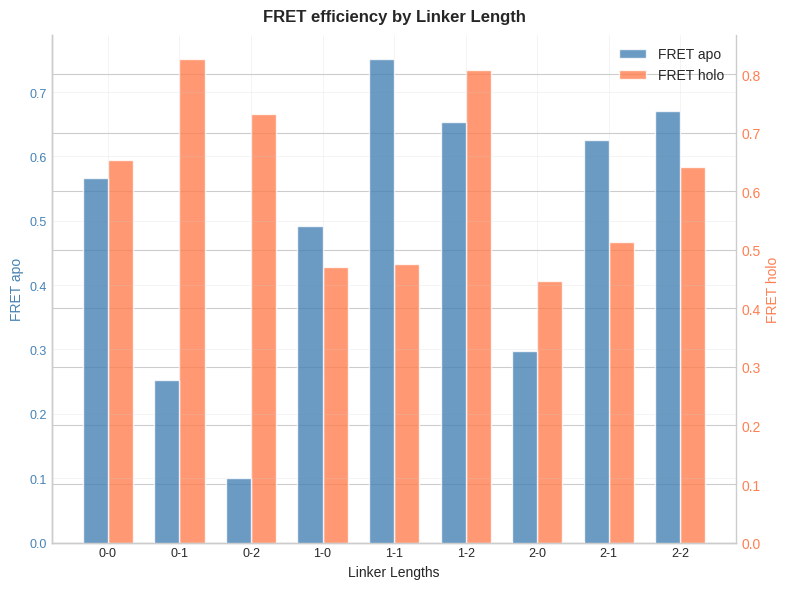
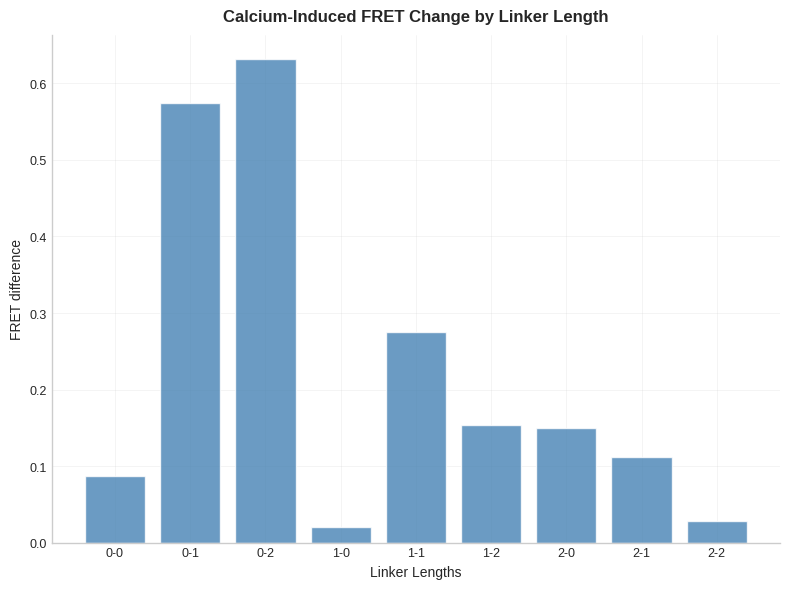

In [3]:
# Cell 3: Pipeline
from biopipelines.pipeline import *
from biopipelines.fuse import Fuse
from biopipelines.boltz2 import Boltz2
from biopipelines.distance import Distance
from biopipelines.panda import Panda
from biopipelines.plot import Plot
from biopipelines.pymol import PyMOL

with Pipeline(project="Biosensor", job="CaFRET"):
    donor = Sequence("VSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLTHGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAA",
                     ids="EBFP")
    acceptor = Sequence("VSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFGYGLQCFARYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSYQSALSKDPNEKRDHMVLLEFVTAA",
                        ids="EYFP")
    cam = Sequence("ADQLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAELQDMINEVDADGNGTIDFPEFLTMMARKMKDTDSEEEIREAFRVFDKDGNGYISAAELRHVMTNLGEKLTDEEVDEMIREADIDGDGQVNYEEFVQMMTAK", ids="CaM")

    fusions = Fuse(sequences=[donor, cam, acceptor],
                   name="CaFRET",
                   linker="GSG",
                   linker_lengths=["0-2", "0-2"])

    apo = Boltz2(proteins=fusions)

    calcium = Ligand("CA")
    holo = Boltz2(proteins=fusions,
                  ligands=Bundle(calcium, calcium, calcium, calcium),
                  msas=apo)

    dist_apo = Distance(structures=apo,
                        residue=["66", "-173"],
                        metric_name="FRET_distance_apo")
    dist_holo = Distance(structures=holo,
                         residue=["66", "-173"],
                         metric_name="FRET_distance_holo")

    R0 = 35.4  # Forster radius for EBFP-EYFP pair (Angstrom), assumes kappa2 = 2/3
    derived_metrics = {"FRET_E_apo": f"1 / (1 + (FRET_distance_apo / {R0}) ** 6)",
                       "FRET_E_holo": f"1 / (1 + (FRET_distance_holo / {R0}) ** 6)",
                       "delta_FRET": "abs(FRET_E_holo - FRET_E_apo)"}

    analysis = Panda(tables=[fusions.tables.sequences,
                              dist_apo.tables.distances,
                              dist_holo.tables.distances],
                     operations=[Panda.merge(),
                                  Panda.calculate(derived_metrics)])

    plots = Plot(Plot.Bar(data=analysis.tables.result,
                  title="FRET efficiency by Linker Length",
                  x="lengths",
                  y="FRET_E_apo",
                  y_right="FRET_E_holo",
                  xlabel="Linker Lengths",
                  ylabel="FRET apo",
                  ylabel_right="FRET holo"),
         Plot.Bar(data=analysis.tables.result,
                  title="Calcium-Induced FRET Change by Linker Length",
                  x="lengths",
                  y="delta_FRET",
                  xlabel="Linker Lengths",
                  ylabel="FRET difference"))
plots

In [4]:
best_apo = Panda(tables=analysis.tables.result,
                 operations=[Panda.sort("delta_FRET",ascending=False),
                             Panda.head(1)],
                 pool=apo)
best_apo


Running Panda (step 12)
=== Activating Environment ===
Requested: biopipelines
Environment: biopipelines
Location: /root/.local/share/mamba/envs/biopipelines
Python: /root/.local/share/mamba/envs/biopipelines/bin/python
Python version: Python 3.12.13
Panda table transformations
Input tables: 1
Operations: sort, head
Output: /content/biopipelines/tests/Biosensor/CaFRET_001/012_Panda/sort_head.csv
Panda: Processing 1 input files
Operations: 2
Rename: Panda_N
Loading: /content/biopipelines/tests/Biosensor/CaFRET_001/010_Panda/merge_calculate.csv
  Shape: (9, 18)
  Columns: ['id', 'sequence', 'lengths', 'sequences_1.id', 'sequences_2.id', 'sequences_3.id', 'S1', 'L1', 'S2', 'L2', 'S3', 'source_structure', 'FRET_distance_apo', 'unit', 'FRET_distance_holo', 'FRET_E_apo', 'FRET_E_holo', 'delta_FRET']

Executing operations:

[1/2] sort
  Sort: by=['delta_FRET'], ascending=False

[2/2] head
  Head: 1

Applied rename: Panda_1 to Panda_1

Final result: (1, 19)
Columns: ['id', 'sequence', 'length

StandardizedOutput({'structures': DataStream(name='structures', format='pdb', items=1, files=1, map_table=set), 'sequences': DataStream(name='sequences', format='csv', items=1, files=0, map_table=set), 'msas': DataStream(name='msas', format='csv', items=1, files=1, map_table=set), 'rendering_parameters': {'structures': {'color_by': 'plddt', 'plddt_upper': 100}}, 'tables': {'result': TableInfo(name='result', path='/content/biopipelines/tests/Biosensor/CaFRET_001/012_Panda/sort_head.csv', columns=['id', 'sequence', 'lengths', 'sequences_1.id', 'sequences_2.id', 'sequences_3.id', 'S1', 'L1', 'S2', 'L2', 'S3', 'FRET_E_apo', 'FRET_E_holo', 'delta_FRET'], count=variable), 'missing': TableInfo(name='missing', path='/content/biopipelines/tests/Biosensor/CaFRET_001/012_Panda/missing.csv', columns=['id', 'removed_by', 'cause'], count=variable), 'structures': TableInfo(name='structures', path='/content/biopipelines/tests/Biosensor/CaFRET_001/012_Panda/structures_map.csv', columns=['id', 'file'], count=9), 'confidence': TableInfo(name='confidence', path='/content/biopipelines/tests/Biosensor/CaFRET_001/012_Panda/confidence_scores.csv', columns=['id', 'input_file', 'confidence_score', 'ptm', 'iptm', 'complex_plddt', 'complex_iplddt'], count=9), 'sequences': TableInfo(name='sequences', path='/content/biopipelines/tests/Biosensor/CaFRET_001/012_Panda/sequences.csv', columns=['id', 'sequence'], count=9), 'msas': TableInfo(name='msas', path='/content/biopipelines/tests/Biosensor/CaFRET_001/012_Panda/msas.csv', columns=['id', 'sequences.id', 'sequence', 'msa_file'], count=9)}, 'output_folder': '/content/biopipelines/tests/Biosensor/CaFRET_001/012_Panda'})

In [5]:
best_holo = Panda(tables=analysis.tables.result,
                  operations=[Panda.sort("delta_FRET",ascending=False),
                              Panda.head(1)],
                  pool=holo)
best_holo


Running Panda (step 13)
=== Activating Environment ===
Requested: biopipelines
Environment: biopipelines
Location: /root/.local/share/mamba/envs/biopipelines
Python: /root/.local/share/mamba/envs/biopipelines/bin/python
Python version: Python 3.12.13
Panda table transformations
Input tables: 1
Operations: sort, head
Output: /content/biopipelines/tests/Biosensor/CaFRET_001/013_Panda/sort_head.csv
Panda: Processing 1 input files
Operations: 2
Rename: Panda_N
Loading: /content/biopipelines/tests/Biosensor/CaFRET_001/010_Panda/merge_calculate.csv
  Shape: (9, 18)
  Columns: ['id', 'sequence', 'lengths', 'sequences_1.id', 'sequences_2.id', 'sequences_3.id', 'S1', 'L1', 'S2', 'L2', 'S3', 'source_structure', 'FRET_distance_apo', 'unit', 'FRET_distance_holo', 'FRET_E_apo', 'FRET_E_holo', 'delta_FRET']

Executing operations:

[1/2] sort
  Sort: by=['delta_FRET'], ascending=False

[2/2] head
  Head: 1

Applied rename: Panda_1 to Panda_1

Final result: (1, 19)
Columns: ['id', 'sequence', 'length

StandardizedOutput({'structures': DataStream(name='structures', format='pdb', items=1, files=1, map_table=set), 'sequences': DataStream(name='sequences', format='csv', items=1, files=0, map_table=set), 'compounds': DataStream(name='compounds', format='csv', items=1, files=1, map_table=set), 'msas': DataStream(name='msas', format='csv', items=1, files=1, map_table=set), 'rendering_parameters': {'structures': {'color_by': 'plddt', 'plddt_upper': 100}}, 'tables': {'result': TableInfo(name='result', path='/content/biopipelines/tests/Biosensor/CaFRET_001/013_Panda/sort_head.csv', columns=['id', 'sequence', 'lengths', 'sequences_1.id', 'sequences_2.id', 'sequences_3.id', 'S1', 'L1', 'S2', 'L2', 'S3', 'FRET_E_apo', 'FRET_E_holo', 'delta_FRET'], count=variable), 'missing': TableInfo(name='missing', path='/content/biopipelines/tests/Biosensor/CaFRET_001/013_Panda/missing.csv', columns=['id', 'removed_by', 'cause'], count=variable), 'structures': TableInfo(name='structures', path='/content/biopipelines/tests/Biosensor/CaFRET_001/013_Panda/structures_map.csv', columns=['id', 'file'], count=9), 'confidence': TableInfo(name='confidence', path='/content/biopipelines/tests/Biosensor/CaFRET_001/013_Panda/confidence_scores.csv', columns=['id', 'input_file', 'confidence_score', 'ptm', 'iptm', 'complex_plddt', 'complex_iplddt'], count=9), 'sequences': TableInfo(name='sequences', path='/content/biopipelines/tests/Biosensor/CaFRET_001/013_Panda/sequences.csv', columns=['id', 'sequence'], count=9), 'msas': TableInfo(name='msas', path='/content/biopipelines/tests/Biosensor/CaFRET_001/013_Panda/msas.csv', columns=['id', 'sequences.id', 'sequence', 'msa_file'], count=9), 'affinity': TableInfo(name='affinity', path='/content/biopipelines/tests/Biosensor/CaFRET_001/013_Panda/affinity_scores.csv', columns=['id', 'input_file', 'affinity_pred_value', 'affinity_probability_binary'], count=9), 'compounds': TableInfo(name='compounds', path='/content/biopipelines/tests/Biosensor/CaFRET_001/013_Panda/compounds.csv', columns=['id', 'format', 'smiles', 'ccd'], count=1)}, 'output_folder': '/content/biopipelines/tests/Biosensor/CaFRET_001/013_Panda'})